In [ ]:
# Google Colab only (does nothing elsewhere): fetch the bundle next to this notebook and install pPXF.
import os, sys, subprocess
os.environ.setdefault("OMP_NUM_THREADS", "1"); os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")     # one core on Colab / Binder
if "google.colab" in sys.modules:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ppxf", "fitsio", "ipywidgets"], check=True)
    if not os.path.exists("interbars_students"):
        subprocess.run(["git", "clone", "--depth", "1", "https://github.com/EdoBorsato/INTERBARS_classes"], check=True)
    os.chdir("interbars_students/notebooks"); print("Colab: working in", os.getcwd())

# Lecture 1 — What a galaxy spectrum is made of, and how pPXF reads it

The question of this course: **is the gas in the nucleus of our barred, interacting galaxies lit up by young
stars or by an active black hole (AGN)?** The evidence is in the optical spectrum of the nucleus. Today:

* **Part 1 — the ingredients of pPXF.** The code we will use to measure the lines models a spectrum as a
  sum of *templates*: stellar-population spectra for the stars, Gaussians for the gas, blurred by the
  motions of stars and gas and dimmed by dust.
* **Appendices B and C — kinematics and dust** (to read at home): how the motions of stars and gas shape
  the lines, including rotation inside the fibre, and how dust reddens the spectrum.
* **Appendix A — a nuclear spectrum** (the slides cover  it). A real
  nuclear spectrum, feature by feature, with a table of what the stars and the gas write in it.

Next lecture: you build mock galaxies by hand (the pPXF model run backwards), then download the spectra
of your galaxies, run pPXF on them for real, and place them on the BPT diagram next to barred and interacting
galaxies.

# Part 1 — The ingredients of pPXF

**pPXF** (penalised PiXel Fitting, Cappellari & Emsellem 2004; Cappellari 2017, 2023) models the spectrum
$G(\lambda)$ of a galaxy as

$$
G_{\rm model}(\lambda) \;=\; \underbrace{\Big[\sum_j w_j\; T_j(\lambda) \ast \mathcal{L}_\star\Big]\, 10^{-0.4\,A_\star(\lambda)}}_{\rm stars}
\;+\; \underbrace{\Big[\sum_k g_k\; E_k(\lambda) \ast \mathcal{L}_{\rm gas}\Big]\, 10^{-0.4\,A_{\rm gas}(\lambda)}}_{\rm gas}
$$

The two sums run over the templates: the index $j$ counts the **stellar templates** ($j = 1, \dots, 150$:
every combination of 25 ages and 6 metallicities), the index $k$ counts the **gas templates** (one per emission
line, $k = 1, \dots, 19$ here). So $w_j$ is the weight of stellar template number $j$, and $g_k$ the weight of gas
template number $k$.

* $T_j$: **stellar templates**, spectra of *simple stellar populations* of given age and metallicity (1.1);
* $E_k$: **gas templates**, one Gaussian per emission line (1.2);
* $\ast\,\mathcal{L}$: convolution with the **line-of-sight velocity distribution** — the Doppler shifts of
  stars or gas clouds moving towards and away from us, a Gaussian of mean $V$ and width $\sigma$ (Appendix B);
* $A(\lambda)$: **dust** attenuation (Appendix C);
* $w_j \ge 0$, $g_k \ge 0$: the **weights**, how much of template $j$ (stars) or $k$ (gas) is in the galaxy.

A *fit* starts from the observed $G(\lambda)$ and finds the weights, $V$, $\sigma$ and the dust that make
$G_{\rm model}$ closest to it (least $\chi^2$). At the start of lecture 2 you will do the opposite: choose them and
look at $G_{\rm model}$.

**Our instrument.** Every template below is matched to a real DESI spectrum — that of IC 3147B — so it
has its wavelength coverage, its pixel size and its spectral resolution. Your mock galaxies will look
exactly like DESI spectra.

**In class** we look at the two kinds of templates (1.1, 1.2) and at the fit itself (1.3). How motions and dust change the templates is in Appendices B and C, to read at home.

In [50]:
import os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS"):    
    os.environ.setdefault(_v, "1")                                          
import sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from ppxf.ppxf import ppxf, attenuation
import ppxf.ppxf_util as util

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
os.environ.setdefault("DESI_SPECTRO_REDUX", str(ROOT / "output" / "desi_redux"))
import lecture_tools as LT                 # readers, line lists, the BPT frame, plotting helpers
C_KMS = 299792.458
plt.rcParams.update({"figure.dpi": 100})
print("repo:", ROOT, "| pPXF", __import__("ppxf").__version__)

repo: /home/eborsato/PyAutoThings/workspace/interbars | pPXF 9.5.0


In [51]:
# The DESI spectrum of IC 3147B, as arrays with one value per pixel:
#   lam_v  wavelength [Å, in vacuum]           flux  flux [1e-17 erg/s/cm²/Å]
#   ivar   inverse variance = 1/σ² of the flux  fwhm  instrumental line width [Å]: how much DESI blurs a sharp line
#   mask   True for bad pixels                   z     the galaxy's redshift;  src = "DESI" or "SDSS"
lam_v, flux, ivar, fwhm, mask, z, src = LT.read("IC3147B")

# Everything pPXF needs, prepared in one go (each step is explained in this Part 1):
#   the spectrum and its noise on a log-wavelength grid, and the stellar and gas templates blurred to the DESI resolution
P = LT.prepare(lam_v, flux, ivar, fwhm, mask, z)

sps = P["sps"]; velscale = P["velscale"]; lam = sps.lam_temp             # the stellar library and its wavelength grid [Å, air]

AGES, METALS = sps.age_grid[:, 0], sps.metal_grid[0]
print(f"stellar library: E-MILES, {len(AGES)} ages ({AGES[0]:.2f}-{AGES[-1]:.1f} Gyr) x {len(METALS)} metallicities {list(METALS)}")
print(f"one pixel = {velscale:.1f} km/s;  instrumental FWHM at Hα = {np.interp(6563 * (1 + z), P['fwhm_gal']['lam'], P['fwhm_gal']['fwhm']):.2f} Å")

def ssp(age, metal=0.0):
    # the template closest to (age [Gyr], [M/H]); normalised to a mean of 1 between 5070 and 5950 Å
    i = np.argmin(abs(np.log10(AGES) - np.log10(age))); j = np.argmin(abs(METALS - metal))
    return sps.templates[:, i, j]

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']
stellar library: E-MILES, 25 ages (0.06-15.8 Gyr) x 6 metallicities [np.float64(-1.71), np.float64(-1.31), np.float64(-0.71), np.float64(-0.4), np.float64(0.0), np.float64(0.22)]
one pixel = 37.8 km/s;  instrumental FWHM at Hα = 1.54 Å


## 1.1 Stellar templates: simple stellar populations

A **simple stellar population** (SSP) is a set of stars all born at the same time with the same chemical
composition, with the number of stars of each mass given by the initial mass function. Its spectrum is
computed by adding up spectra of real stars (the MILES library) along a stellar-evolution isochrone. A
galaxy is then a sum of SSPs: its star-formation history.

Every template is normalised to a mean of 1 between 5070 and 5950 Å (the V band). So a weight of 0.3
means *"this population gives 30 % of the light at 5500 Å"*: weights are **light fractions**.

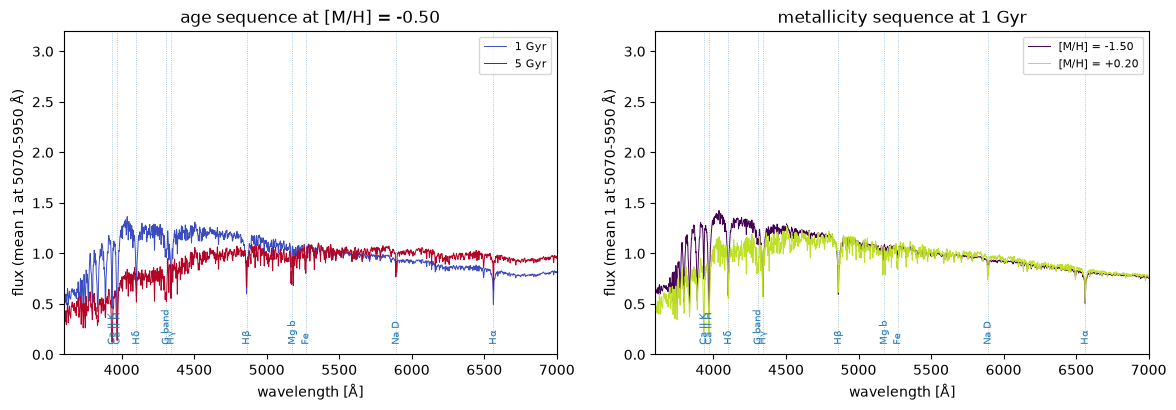

In [62]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.2))

ages = [1, 5]
metal_at_ages = -0.5

metals = [-1.5, 0.2]
age_at_metals = 1

for age, c in zip(ages, plt.cm.coolwarm(np.linspace(0, 1, len(ages)))):
    axs[0].plot(lam, ssp(age, metal_at_ages), color=c, lw=0.7, label=f"{age:g} Gyr")
    
for met, c in zip(metals, plt.cm.viridis(np.linspace(0, 0.9, len(metals)))):
    axs[1].plot(lam, ssp(age_at_metals, met), color=c, lw=0.7, label=f"[M/H] = {met:+.2f}")
    
axs[0].set_title(f"age sequence at [M/H] = {metal_at_ages:+.2f}"); axs[1].set_title(f"metallicity sequence at {age_at_metals} Gyr")

for ax in axs:
    ax.set(xlim=(3600, 7000), ylim=(0, 3.2), xlabel="wavelength [Å]", ylabel="flux (mean 1 at 5070-5950 Å)"); LT.annotate(ax, kinds=("absorption",), fontsize=7); ax.legend(fontsize=8, loc="upper right")
plt.show()

**Questions**

1. Young populations are bright in the blue: which stars dominate their light? Why does the blue fade
   with age?
2. At which age are the Balmer absorption lines (Hδ, Hγ, Hβ) deepest? (Try `ssp(0.5)` against `ssp(0.06)`
   and `ssp(10)`, zoomed on 4000–4400 Å.) Which stars are responsible?
3. Metallicity and age both redden the spectrum and deepen the metal lines. Find an older metal-poor and a
   younger metal-rich template that look almost the same: this is the **age–metallicity degeneracy**.

## 1.2 Gas templates

Each gas template is one emission line — a Gaussian at the instrumental width, normalised to unit
area — later broadened by the gas σ just like the stars (Appendix B). Lines whose ratio is fixed by atomic physics
come as one template: [O III] 4959 : 5007 = 1 : 3, [N II] 6548 : 6583 = 1 : 3, [O I] 6300 : 6364 = 3 : 1
(names ending in `_d`). The weight $g_k$ of a template is then simply the **flux of that line**.

Emission lines included in gas templates:
['H10' 'H9' 'H8' 'Heps' 'Hdelta' 'Hgamma' 'Hbeta' 'Halpha' '[OII]3726'
 '[OII]3729' '[SII]6716' '[SII]6731' '[NeIII]3968' '[NeIII]3869'
 'HeII4687' 'HeI5876' '[OIII]5007_d' '[OI]6300_d' '[NII]6583_d']


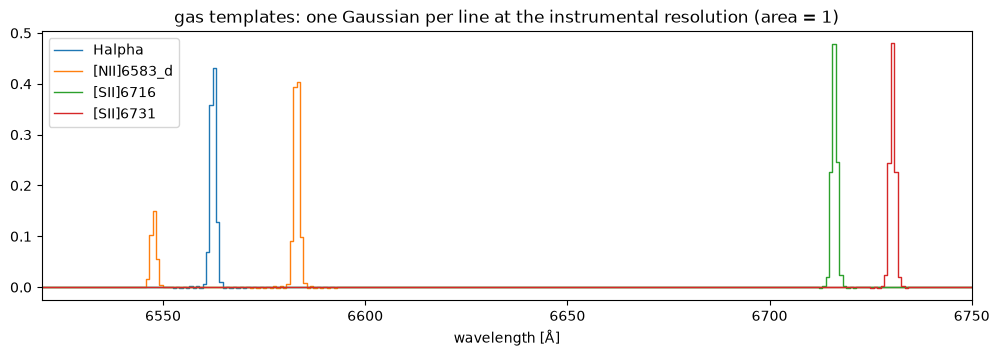

In [4]:
gas_t, gas_names, line_wave = util.emission_lines(
    sps.ln_lam_temp,   # the wavelength grid of the templates (log), so gas and stellar templates line up
    [3500, 9600],      # the rest-wavelength range [Å]: lines outside it are left out
    P["fwhm_gal"],     # the instrumental FWHM [Å] at each wavelength: each line gets the width DESI gives it
    tie_balmer=False,  # Hα, Hβ, Hγ… fitted freely (True would fix their ratios to the dust-free values)
    limit_doublets=False   # [S II] and [O II] doublets free; [O III], [N II], [O I] always come as fixed 1:3 pairs
)

gas_names = list(gas_names)

fig, ax = plt.subplots(figsize=(12, 3.5))

for name in ["Halpha", "[NII]6583_d", "[SII]6716", "[SII]6731"]:
    ax.step(lam, gas_t[:, gas_names.index(name)], lw=1, label=name)
    
ax.set(xlim=(6520, 6750), xlabel="wavelength [Å]", title="gas templates: one Gaussian per line at the instrumental resolution (area = 1)"); ax.legend(); plt.show()

### Exercise: you set the emission lines

Each gas template is multiplied by a weight, the **flux** of that line. Choose the fluxes yourself (relative to
Hα = 1) and watch the gas spectrum, and where it falls on the BPT diagram. The [N II] and [O III] values are the
strong line of each pair; its weak partner follows automatically at 1 : 3. [S II] is the total of its two lines.

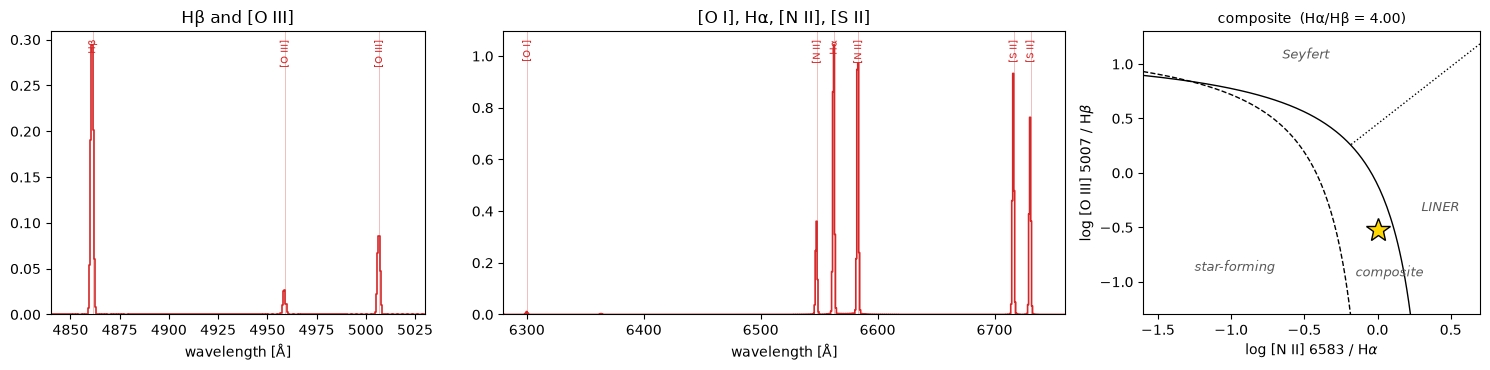

In [65]:
def gas_spectrum(fluxes):
    # weight of a template = line flux / pixel size [Å] at that line (each template has unit area in pixels)
    return sum(f / (line_wave[gas_names.index(n)] * velscale / C_KMS) * gas_t[:, gas_names.index(n)] for n, f in fluxes.items())

def show_gas(ha=1.0, hb=0.35, nii=0.30, oiii=0.25, sii=0.35, oi=0.05):
    fluxes = {"Halpha": ha, "Hbeta": hb, "[NII]6583_d": nii, "[OIII]5007_d": oiii, "[SII]6716": 0.55 * sii, "[SII]6731": 0.45 * sii, "[OI]6300_d": oi}
    spec = gas_spectrum(fluxes)
    fig, axs = plt.subplots(1, 3, figsize=(15, 3.8), gridspec_kw=dict(width_ratios=[1, 1.5, 0.9]))
    for ax, (lo, hi, title) in zip(axs[:2], [(4840, 5030, "Hβ and [O III]"), (6280, 6760, "[O I], Hα, [N II], [S II]")]):
        s = (lam > lo) & (lam < hi); ax.step(lam[s], spec[s], color="tab:red", lw=1.2)
        ax.set(xlim=(lo, hi), ylim=(0, None), xlabel="wavelength [Å]", title=title); LT.annotate(ax, kinds=("emission",), fontsize=7)
    x, y = np.log10(nii / ha), np.log10(oiii / hb)
    LT.bpt_frame(axs[2]); axs[2].plot(x, y, "*", ms=18, color="gold", mec="k", zorder=5)
    axs[2].set_title(f"{LT.bpt_class(x, y)}  (Hα/Hβ = {ha / hb:.2f})", fontsize=10)
    fig.tight_layout(); plt.show()

show_gas(ha=2.0, hb=0.5, nii=2.0, oiii=0.15, sii=3, oi=0.02)                      # a star-forming nucleus; change the numbers, e.g. show_gas(nii=1.0, oiii=3.5)

**Questions**

1. Turn the star-forming nucleus into a **Seyfert 2**. Which lines did you have to change, and by how much?
2. Make a **LINER**: strong [N II], [S II] and [O I], but modest [O III]. Where does it land?
3. Dust dims Hβ and [O III] almost equally (they are close in wavelength). Lower both by the same factor: does
   the point move on the BPT? What does change? (Appendix C)
4. Why can you not choose [N II] 6548 separately from [N II] 6583?

## 1.3 pPXF at work

Put the ingredients together and let pPXF find the weights. For given kinematics ($V$, $\sigma$) the model is
**linear** in the weights, so pPXF solves for all of them at once with the constraint $w_j \ge 0$; around
that it searches the few **non-linear** parameters — $V$ and $\sigma$ of each component, and $A_V$ — for the
lowest $\chi^2 = \sum_i [(G_i - G_{{\rm model},i})/\sigma_i]^2$.

Below: IC 3147B, with all 150 stellar templates, the gas templates in two kinematic components (Balmer and
forbidden lines) and Calzetti dust on the stars. The two kinematic components and the dust are explained in Appendices B and C.

χ²/N = 1.79;  σ⋆ = 102 km/s,  σ_gas = 98 / 151 km/s (Balmer / forbidden),  A_V⋆ = 0.59


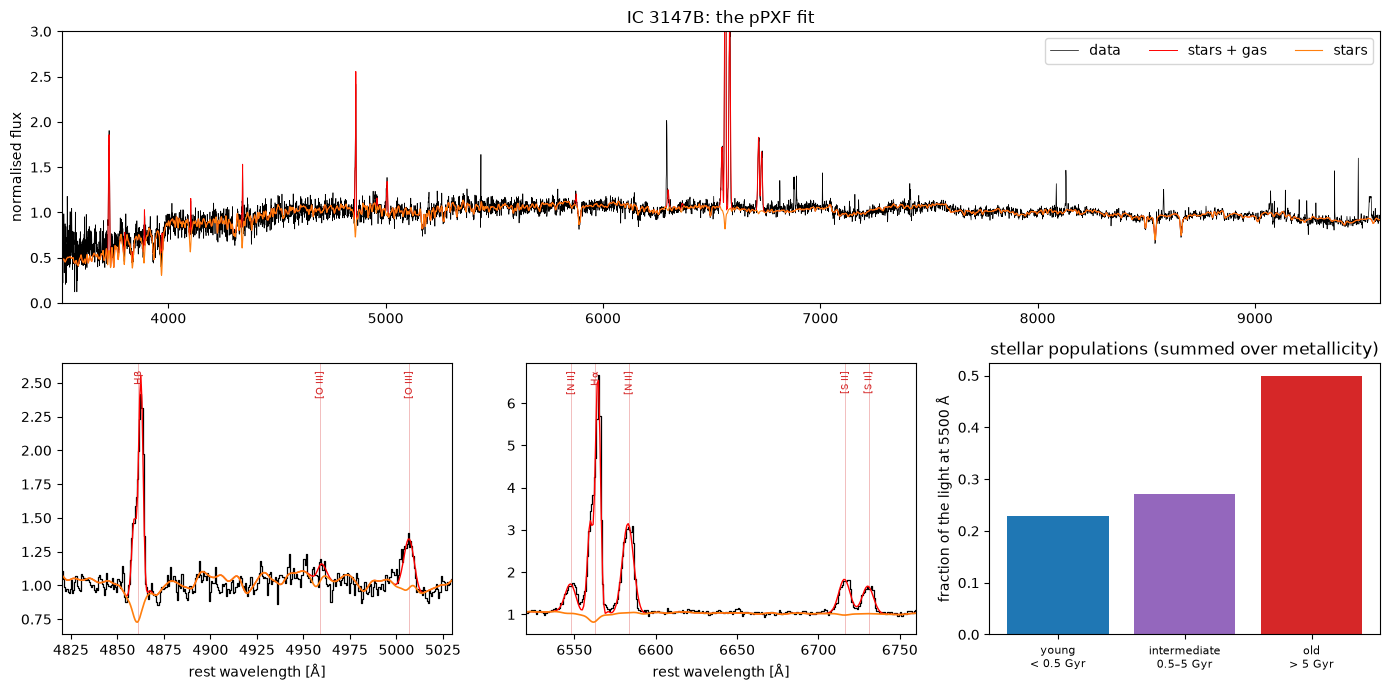

In [67]:

# Fit
stars_t = sps.templates.reshape(sps.templates.shape[0], -1); n_st = stars_t.shape[1]   # the 25 ages x 6 metallicities as 150 columns

forb = np.array(["[" in n for n in gas_names])   # True for forbidden lines ([O III], [N II], ...), False for Balmer lines

templates = np.column_stack([stars_t, gas_t]); component = [0] * n_st + [2 if f else 1 for f in forb]   # all templates side by side; component: 0 = stars, 1 = Balmer, 2 = forbidden

vel = C_KMS * np.log(1 + z)   # the redshift as a velocity [km/s]: the starting guess for V

pp = ppxf(
    templates,                    # every template, one per column: 150 stellar populations + the gas lines
    P["galaxy"],                  # the spectrum to fit, on the log-wavelength grid, normalised to ~1
    P["noise"],                   # its 1σ error per pixel: noisy pixels count less in χ²
    velscale,                     # the size of one pixel in km/s (Appendix B.1)
    [[vel, 100], [vel, 80], [vel, 80]],   # starting guess of (V, σ) [km/s] for stars, Balmer lines, forbidden lines
    moments=[2, 4, 2],            # fit 2 numbers (V and σ) for each of the 3 kinematic components
    degree=-1,                    # no additive polynomial (it could fake or hide absorption lines)
    mdegree=-1,                   # no multiplicative polynomial: the continuum shape must come from stars and dust alone
    lam=P["lam_gal"],             # wavelength of each pixel of the spectrum [Å]
    lam_temp=lam,                 # wavelength of each pixel of the templates [Å]
    component=component,          # which kinematic component each template belongs to
    gas_component=np.array(component) > 0,   # which templates are gas: their weights become line fluxes
    gas_names=np.array(gas_names),           # names for the gas templates, used in the printed output
    goodpixels=P["goodpixels"],   # pixels used in the fit: bad pixels, a sky line and a telluric band are left out
    reddening=0.2,                # also fit the dust A_V on the stars (Calzetti curve), starting from 0.2 mag
    quiet=True                    # do not print the iterations
)

print(f"χ²/N = {pp.chi2:.2f};  σ⋆ = {pp.sol[0][1]:.0f} km/s,  σ_gas = {pp.sol[1][1]:.0f} / {pp.sol[2][1]:.0f} km/s (Balmer / forbidden),  A_V⋆ = {pp.reddening:.2f}")

w = pp.weights[:n_st].reshape(sps.templates.shape[1:]); w = w / w.sum()

rest = P["lam_gal"] / (1 + z); stars_fit = pp.bestfit - pp.gas_bestfit


# Figure
fig = plt.figure(figsize=(14, 7)); gs = fig.add_gridspec(2, 3)

ax = fig.add_subplot(gs[0, :]); ax.plot(rest, P["galaxy"], "k", lw=0.5, label="data"); ax.plot(rest, pp.bestfit, "r", lw=0.7, label="stars + gas")
ax.plot(rest, stars_fit, color="tab:orange", lw=0.8, label="stars"); ax.set(xlim=(rest[0], rest[-1]), ylim=(0, 3), ylabel="normalised flux", title="IC 3147B: the pPXF fit"); ax.legend(ncol=3)

for k, (lo, hi) in enumerate([(4820, 5030), (6520, 6760)]):
    a = fig.add_subplot(gs[1, k]); s_ = (rest > lo) & (rest < hi)
    a.plot(rest[s_], P["galaxy"][s_], "k", lw=0.9, drawstyle="steps-mid"); a.plot(rest[s_], pp.bestfit[s_], "r", lw=1); a.plot(rest[s_], stars_fit[s_], color="tab:orange", lw=1.2)
    a.set(xlim=(lo, hi), xlabel="rest wavelength [Å]"); LT.annotate(a, kinds=("emission",), fontsize=7)
    
bins = {"young\n< 0.5 Gyr": AGES < 0.5, "intermediate\n0.5–5 Gyr": (AGES >= 0.5) & (AGES < 5), "old\n> 5 Gyr": AGES >= 5}

a = fig.add_subplot(gs[1, 2]); fr = [w[m].sum() for m in bins.values()]

a.bar(range(3), fr, color=["tab:blue", "tab:purple", "tab:red"]); a.set_xticks(range(3)); a.set_xticklabels(list(bins), fontsize=8)

a.set(ylabel="fraction of the light at 5500 Å", title="stellar populations (summed over metallicity)")

fig.tight_layout(); plt.show()

**Read the result**

* The red model follows the data everywhere; the orange stellar part fills the absorption troughs under Hβ
  and Hα, so the gas lines are measured on top of the *right* continuum (Appendix A.3).
* The light comes from a mixture: young, intermediate and old populations together — a nucleus with
  ongoing star formation on top of an old bulge. pPXF itself returns one weight per template (150 of them),
  but neighbouring ages and metallicities can trade places (the degeneracies of 1.1), so we sum them into broad
  age bins, which are robust. Try `LT.light_map(plt.gca(), w, AGES, METALS)` to see the raw weights.
* The gas moves differently from the stars (compare σ_gas and σ⋆): two kinematic components were needed.
* `pp.gas_flux` holds the weight of every gas template, i.e. the **line fluxes**: the four BPT lines are
  among them. That is the measurement of lecture 2.

## Before lecture 2

* Look at the sample montage on the slides and pick the system you want to work on.
* Optional reading: the pPXF page on PyPI (https://pypi.org/project/ppxf/) and Cappellari (2023, MNRAS 526, 3273), section 1.

# Appendix A — Anatomy of a nuclear spectrum

*Reference material: the slides of lecture 1 show the same figures. Read it at home, or come back to it while you work on lecture 2.*

## Appendix A.1 One spectrum, feature by feature

This is the nucleus of **IC 3147B**, one of the galaxies of the sample, observed by the DESI survey with a
fibre 1.5″ across (0.7 kpc at the galaxy). The wavelength is in the galaxy's **rest frame** (the observed
wavelength divided by $1+z$), and the flux is normalised to about 1.

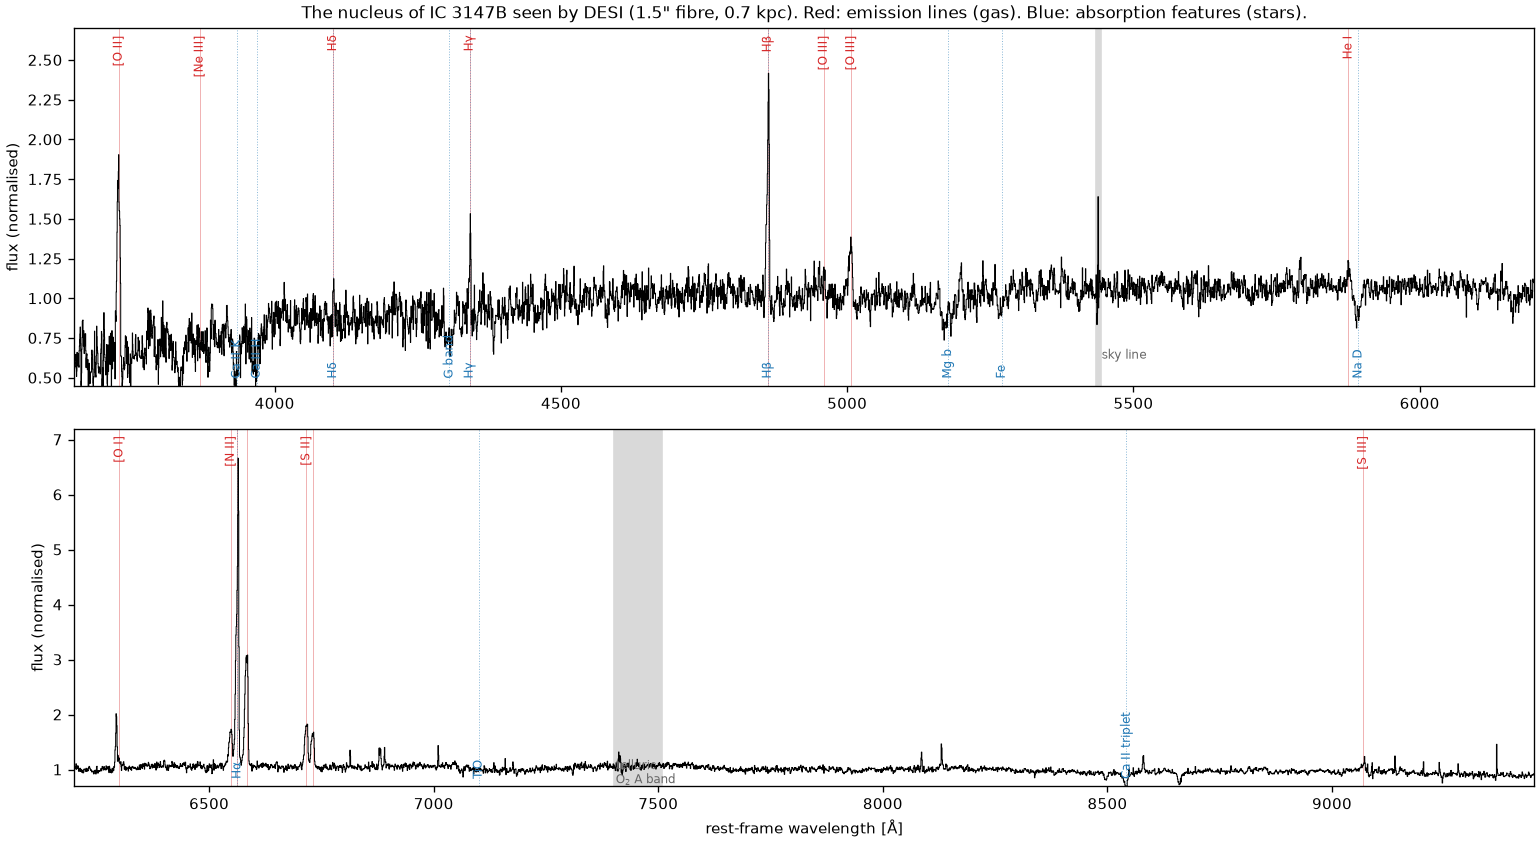

The spectrum has three ingredients:

1. **The continuum** — the summed light of ~$10^9$ stars. Its overall shape (here: rising from the blue,
   flat in the red) says how hot, i.e. how young, the stars are.
2. **Absorption features (blue labels)** — atoms and molecules in the stellar atmospheres absorbing at
   their own wavelengths. Which ones are strong depends on the stars' temperature, so on the population's
   age and metal content.
3. **Emission lines (red labels)** — photons emitted by *ionised gas*. Something must keep the gas ionised:
   hot young stars (an H II region) or the radiation of an accreting black hole (an AGN). The *ratios* of
   the lines tell the two apart.

Not every spike belongs to the galaxy: the grey bands mark the residual of the brightest **sky line**
(5577 Å observed) and the **telluric O₂ A band** (7600 Å observed, absorbed by our own atmosphere); the
narrow spikes beyond 8000 Å are residuals of the sky's OH lines.

| feature | rest λ [Å] | made by | what it tells us |
|---|---|---|---|
| [O II] 3726, 3729 | 3727 | gas | ionised gas; star formation tracer in the blue |
| **Hβ** 4861, **Hα** 6563 (and Hγ, Hδ) | | gas (recombining hydrogen) | *how much* gas is ionised; Hα/Hβ measures dust |
| **[O III]** 4959, 5007 | | gas, O²⁺ | needs energetic photons: strong in AGN |
| **[N II]** 6548, 6583 | | gas, N⁺ | strong when the ionising spectrum is hard (AGN) |
| [S II] 6716, 6731 | | gas, S⁺ | low ionisation; their ratio gives the gas density |
| [O I] 6300 | | gas, neutral O | partly-ionised zones: AGN, LINERs, shocks |
| Ca II **K** 3934 and **H** 3969 | | stars (cool, old) | with the **4000 Å break**: the age of the population |
| Balmer absorption Hδ, Hγ, Hβ, Hα | | stars (A type) | strongest 0.1–1 Gyr after a burst of star formation |
| G band 4304, Mg b 5175, Fe 5270 | | stars (cool) | old, metal-rich populations; their width gives σ⋆ |
| Na D 5890, 5896 | | stars **and** interstellar gas | cool stars, plus cold gas in front of them |
| Ca II triplet 8498, 8542, 8662 | | red giants | stellar kinematics in the near-infrared |

*Square brackets* ([O III], [N II]) mark **forbidden** lines: transitions so slow that on Earth a
collision de-excites the atom first. They are seen only in very low-density gas — exactly the gas of
H II regions and AGN narrow-line regions.

## Appendix A.2 Same features, two nuclei

Top: the nucleus of **IC 775**, an old bulge with almost no gas. Bottom: IC 3147B again. The orange curve
is the stellar model that pPXF finds (Part 1 explains how).

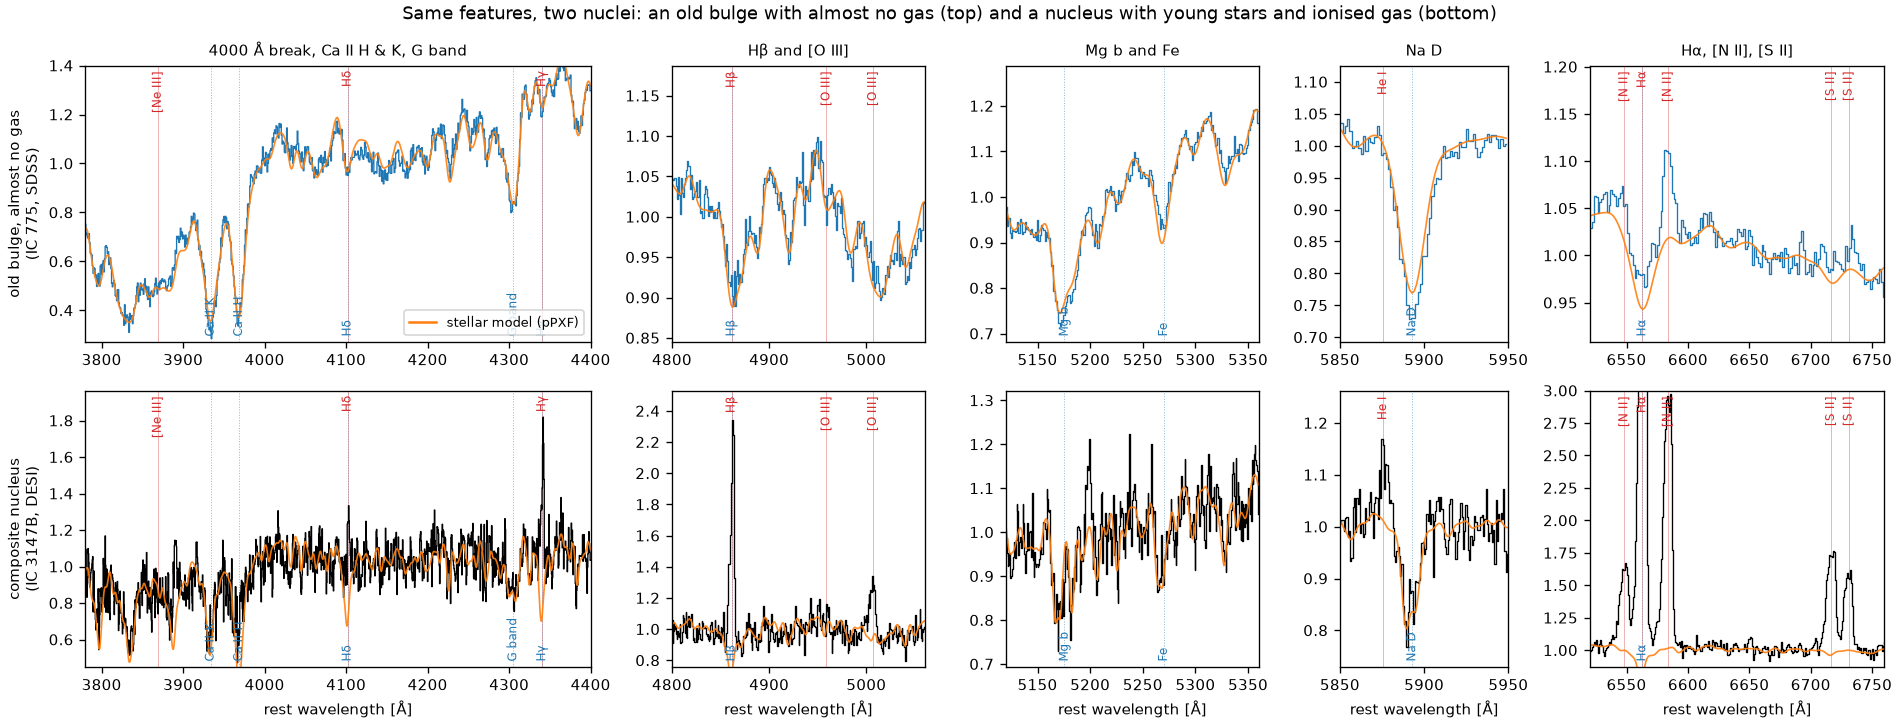

**Look and discuss**

* The **4000 Å break**: which nucleus has the bigger jump in flux across 4000 Å? Old populations have a
  strong break, because their cool stars absorb heavily in the many metal lines just blueward of it.
* **Hβ** in the top row is *absorption*; in the bottom row it is mostly *emission*, but notice the orange
  trough under it: the emission line sits **inside** a stellar absorption line.
* **Mg b** and **Na D** are deep in the old bulge and shallower in IC 3147B: younger, hotter stars dilute
  the metal lines of the old ones.
* The absorption lines of the old bulge are **broader** — its stars move faster (σ⋆ ≈ 300 km/s against
  ≈ 100 km/s). A spectrum measures motions too.

## Appendix A.3 A spectrum = stars + gas

pPXF splits the spectrum into a **stellar part** (orange: a weighted sum of stellar-population templates)
and a **gas part** (red: Gaussian emission lines). The green curve is what is left: noise, plus the sky
residuals.

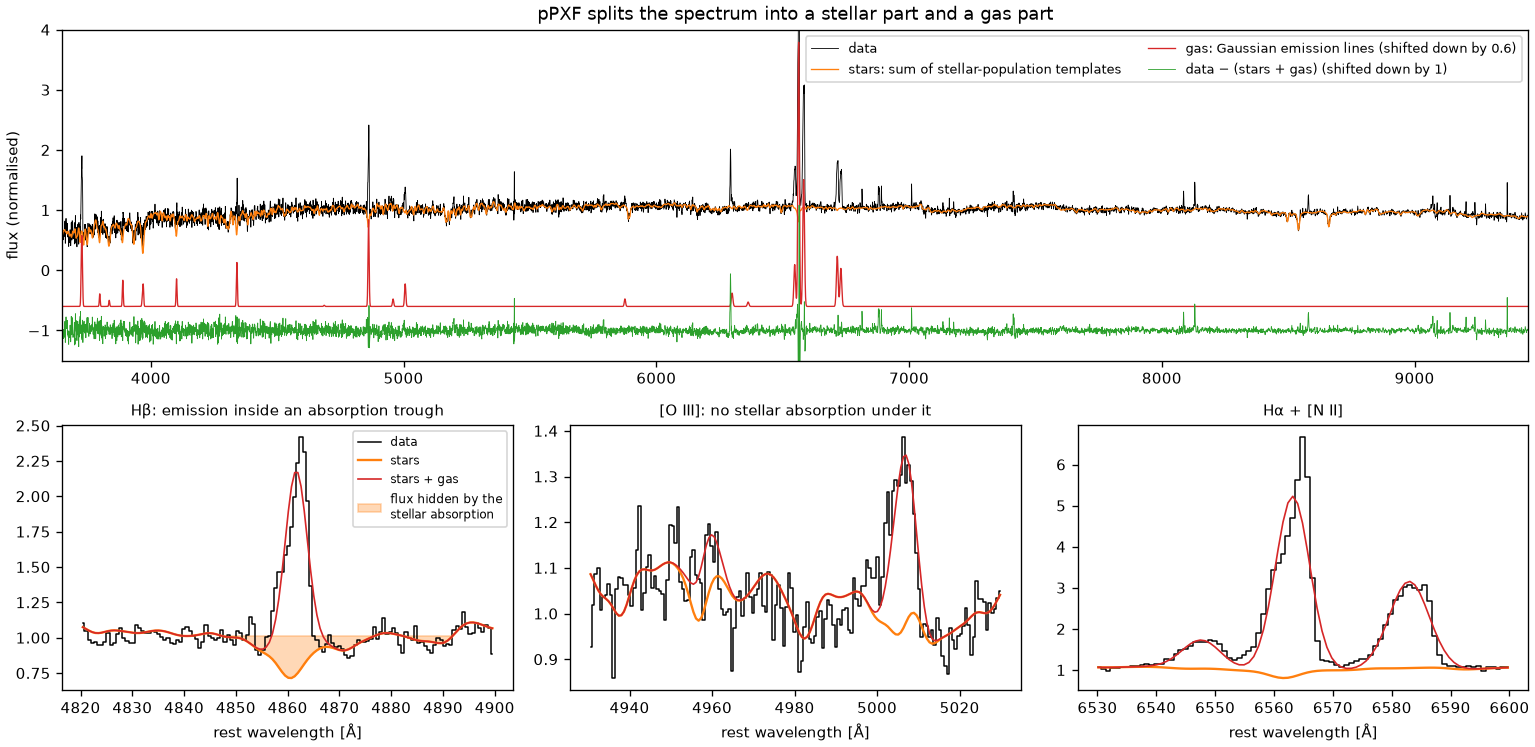

The left zoom is the reason we need this decomposition at all. If you drew a straight line under Hβ and
measured the flux above it, you would miss the shaded flux eaten by the stellar absorption — about 20 %
here. Since Hβ is one of the four lines of the BPT diagram, **you cannot classify the gas without first
modelling the stars**. [O III] has no stellar line under it; Hα has a weaker one.

## Appendix A.4 Three kinds of nuclei

Three nuclei of the sample, zoomed on the lines of the BPT diagram: Hβ and [O III] (left), Hα and [N II]
(middle). The right panel places their **line ratios** on the BPT diagram (Baldwin, Phillips & Terlevich
1981).

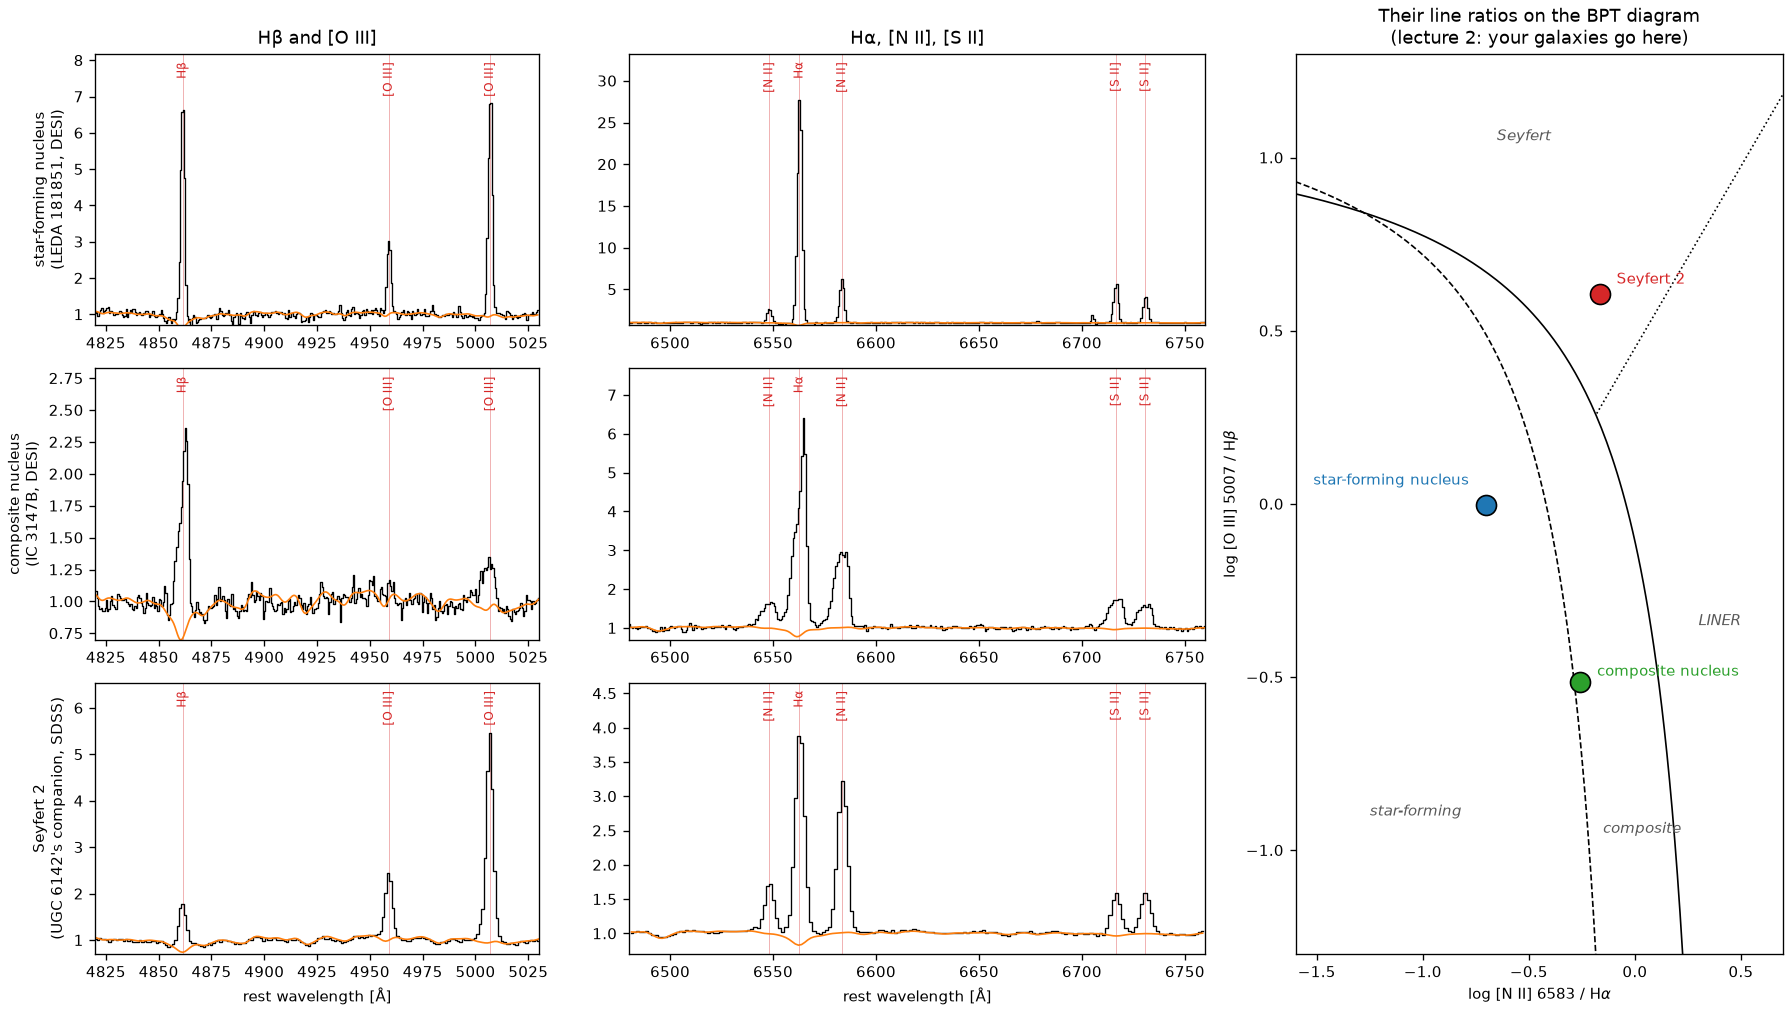

* **Star-forming**: Hα much stronger than [N II]; [O III]/Hβ moderate. The gas is ionised by O and B stars.
* **Seyfert 2**: [O III] five times Hβ, [N II] almost as strong as Hα. An AGN emits many more high-energy
  photons than a star: they keep oxygen doubly ionised ([O III]) and heat a large partly-ionised zone
  where [N II], [S II] and [O I] shine.
* **Composite**: in between — star formation and an AGN (or shocks) both contribute to the fibre.

The curves on the BPT separate star-forming galaxies (left of the dashed Kauffmann et al. 2003 line) from
those that need an AGN (right of the solid Kewley et al. 2001 "maximum starburst" line).
(A **Seyfert 1**, where we look straight at the black hole's surroundings, adds broad wings to Hα and Hβ;
one galaxy of the sample has them, and whoever picks it gets a notebook of its own.)
**Lecture 2: your galaxies go on this diagram.**

# Appendix B — Kinematics: how motions shape the lines

*To read at home.* Stars and gas move: the whole galaxy recedes from us, and inside it stars and gas clouds move
in all directions. These motions shift and broaden every line. This appendix shows how pPXF handles them.

## B.1 Velocity, redshift and the logarithmic grid

A Doppler shift multiplies every wavelength by the same factor, $\lambda_{\rm obs} = \lambda\,(1 + V/c)$.
On a grid of $\ln\lambda$ that is a **constant shift**: $\ln\lambda_{\rm obs} = \ln\lambda + \ln(1+V/c)$.
pPXF therefore resamples spectra and templates onto pixels of constant $\Delta\ln\lambda$, i.e. of constant
velocity width `velscale` (here ~38 km/s). Shifting by $V$ is then just moving by $V/$`velscale` pixels,
and broadening by $\sigma$ is a convolution with a Gaussian $\sigma/$`velscale` pixels wide.

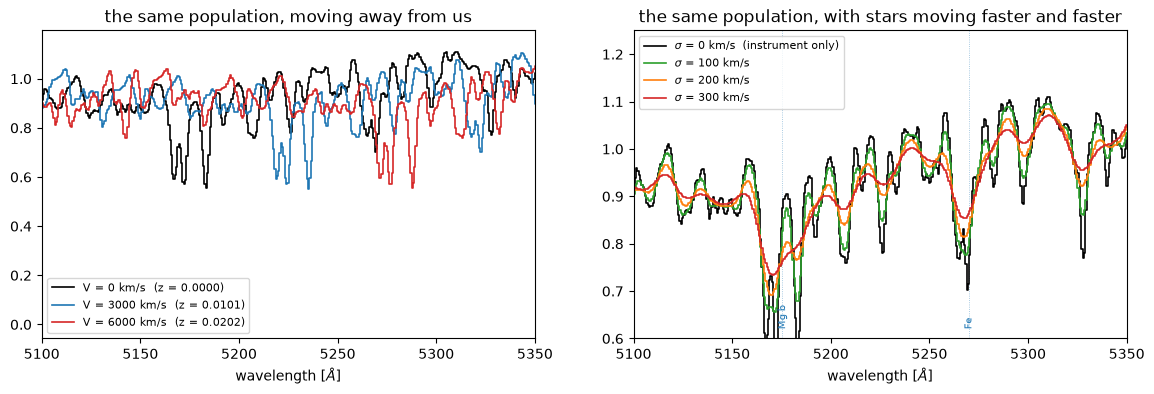

In [8]:
def broaden(spec, V=0.0, sigma=0.0):
    # convolve a spectrum on the log grid with a Gaussian LOSVD of mean V and width sigma [km/s].
    n = spec.size; npad = 2 ** int(np.ceil(np.log2(2 * n)))
    w = 2 * np.pi * np.fft.rfftfreq(npad)                                           # angular frequency [rad / pixel]
    kernel = np.exp(-1j * w * V / velscale - 0.5 * (w * sigma / velscale) ** 2)
    return np.fft.irfft(np.fft.rfft(spec, npad) * kernel, npad)[:n]

old = ssp(10, 0.0)

fig, axs = plt.subplots(1, 2, figsize=(14, 4))

for V, c in zip([0, 3000, 6000], ["k", "tab:blue", "tab:red"]):
    axs[0].step(lam, broaden(old, V=V), color=c, lw=1.2, label=f"V = {V} km/s  (z = {np.exp(V / C_KMS) - 1:.4f})")
    
axs[0].set(xlim=(5100, 5350), xlabel="wavelength [$\\AA$]", title="the same population, moving away from us"); axs[0].legend(fontsize=8)

for s_, c in zip([0, 100, 200, 300], ["k", "tab:green", "tab:orange", "tab:red"]):
    axs[1].step(lam, broaden(old, sigma=s_), color=c, lw=1.2, label=f"$\\sigma$ = {s_} km/s" + ("  (instrument only)" if s_ == 0 else ""))
    
axs[1].set(xlim=(5100, 5350), ylim=(0.6, 1.25), xlabel="wavelength [$\\AA$]", title="the same population, with stars moving faster and faster"); axs[1].legend(fontsize=8)

LT.annotate(axs[1], kinds=("absorption",)); plt.show()

**Questions**

1. The velocity dispersion σ⋆ broadens the lines without changing their *area* (equivalent width). What
   happens to the *depth* of Mg b? Could a large σ⋆ be confused with a lower metallicity?
2. A galaxy at $z = 0.02$ recedes at about 6000 km/s. Through how many pixels does that shift the spectrum?
3. σ = 0 is not infinitely sharp: the templates have already been blurred to the DESI resolution. What
   would happen to a galaxy with σ⋆ = 20 km/s, well below the instrumental σ (~ 30–50 km/s)?

## B.2 Kinematics: stars and gas move differently

pPXF can assign the templates to separate **kinematic components**, each with its own $V$ and $\sigma$.
In this course: component 0 = stars, 1 = the Balmer lines (Hα, Hβ, …), 2 = the forbidden lines ([O III],
[N II], …). The gas in a disc is *cold* (σ ~ 50–100 km/s), the stars of a bulge are *hot* (σ⋆ ~ 100–300
km/s); gas stirred by an AGN outflow is broader still.

### Rotation inside the fibre

A fibre does not resolve the nucleus: it adds up the light of everything inside it. If the gas (or the stars)
rotate, the side of the disc coming towards us is blueshifted and the side moving away is redshifted, and the
sum is a **broader line**, which pPXF reads as a larger σ. The cell below builds a thin disc with a realistic
rotation curve, puts a 3″ SDSS fibre (0.8 kpc at our redshifts) on it and adds up the lines. The "looks like σ"
numbers are the single-Gaussian width you would measure.

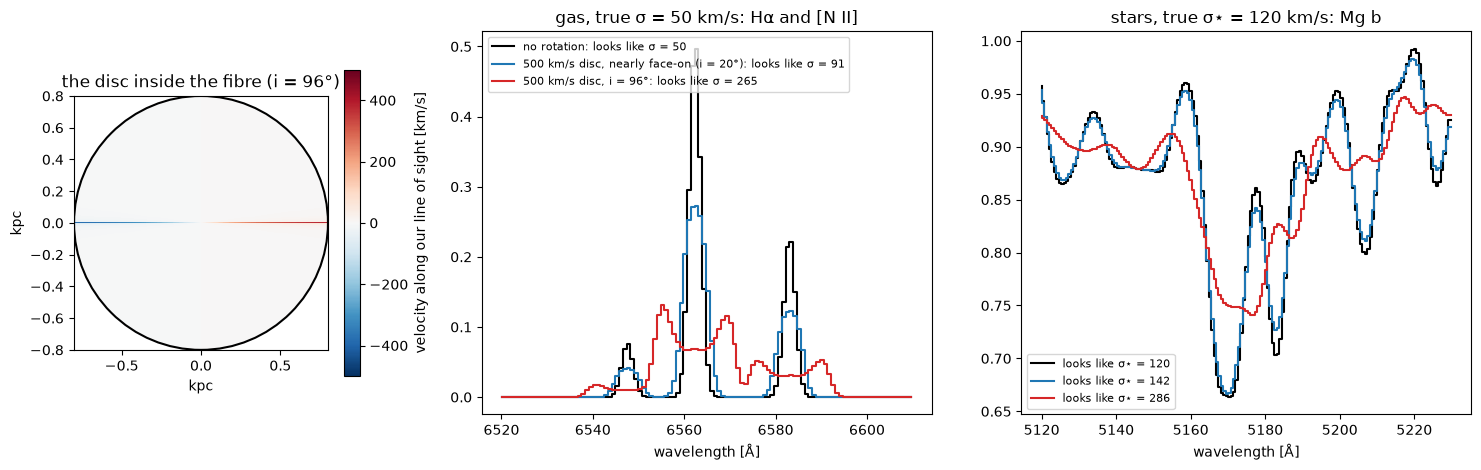

In [69]:
V_MAX, INCL, R_FIBRE = 500, 96, 0.8      # <-- try: rotation speed [km/s], inclination [deg; 0 = face-on], fibre radius [kpc; SDSS 3" ~ 0.8, DESI 1.5" ~ 0.4]

def fibre_losvd(v_max, incl_deg, r_fibre=0.8, r_turn=0.3, h=1.0, n=301):
    # line-of-sight velocities of a thin rotating disc seen through a round fibre of radius r_fibre [kpc]:
    # rotation curve V(R) = v_max * 2/pi * arctan(R / r_turn), surface brightness exp(-R / h), inclination i
    x, y = np.meshgrid(np.linspace(-r_fibre, r_fibre, n), np.linspace(-r_fibre, r_fibre, n))
    inside = x**2 + y**2 <= r_fibre**2
    i = np.radians(incl_deg); R = np.hypot(x, y / max(np.cos(i), 1e-3))           # radius in the plane of the disc
    v_los = v_max * 2 / np.pi * np.arctan(R / r_turn) * np.sin(i) * x / np.maximum(R, 1e-9)
    w = np.exp(-R / h) * inside
    edges = (np.arange(-60, 62) - 0.5) * velscale                                   # one bin per pixel of the log grid, centred on 0
    kernel = np.histogram(v_los[inside], bins=edges, weights=w[inside])[0]
    return kernel / kernel.sum(), (x, y, np.where(inside, v_los, np.nan))

def observe(spec, sigma, kernel):
    # random motions (a Gaussian of width sigma) + rotation inside the fibre (the kernel)
    return np.convolve(broaden(spec, sigma=sigma), kernel, mode="same")

def sigma_apparent(sigma, kernel):
    # the width a single Gaussian would need: random motions and rotation add in quadrature
    v = (np.arange(kernel.size) - kernel.size // 2) * velscale
    return np.sqrt(sigma**2 + np.sum(kernel * v**2))

# the gas: Hα and [N II] at the instrumental resolution
fwhm_ha = np.interp(6563, P["fwhm_gal"]["lam"] / (1 + z), P["fwhm_gal"]["fwhm"])
line = lambda w0, f: f * np.exp(-0.5 * ((lam - w0) / (fwhm_ha / 2.355)) ** 2)
gas = line(6562.8, 1.0) + line(6583.5, 0.45) + line(6548.0, 0.15)
old = ssp(10)

cases = [("no rotation", 0, 0), (f"{V_MAX} km/s disc, nearly face-on (i = 20°)", V_MAX, 20), (f"{V_MAX} km/s disc, i = {INCL}°", V_MAX, INCL)]

fig = plt.figure(figsize=(15, 4.8)); gs = fig.add_gridspec(1, 3, width_ratios=[0.85, 1.2, 1.2])

_, (x, y, vmap) = fibre_losvd(V_MAX, INCL, R_FIBRE)

ax = fig.add_subplot(gs[0]); vlim = max(V_MAX, 1)
im = ax.pcolormesh(x, y, vmap, cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto"); ax.set_aspect("equal")

ax.add_patch(plt.Circle((0, 0), R_FIBRE, fill=False, color="k", lw=1.5)); plt.colorbar(im, ax=ax, shrink=0.8, label="velocity along our line of sight [km/s]")
ax.set(title=f"the disc inside the fibre (i = {INCL}°)", xlabel="kpc", ylabel="kpc")

a1, a2 = fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

for (label, vmax, inc), col in zip(cases, ["k", "tab:blue", "tab:red"]):
    k = fibre_losvd(vmax, inc, R_FIBRE)[0] if vmax else np.array([1.0])
    s1 = (lam > 6520) & (lam < 6610); a1.step(lam[s1], observe(gas, 50, k)[s1], color=col, lw=1.5, label=f"{label}: looks like σ = {sigma_apparent(50, k):.0f}")
    s2 = (lam > 5120) & (lam < 5230); a2.step(lam[s2], observe(old, 120, k)[s2], color=col, lw=1.5, label=f"looks like σ⋆ = {sigma_apparent(120, k):.0f}")
    
a1.set(title="gas, true σ = 50 km/s: Hα and [N II]", xlabel="wavelength [Å]"); a1.legend(fontsize=8, loc="upper left")
a2.set(title="stars, true σ⋆ = 120 km/s: Mg b", xlabel="wavelength [Å]"); a2.legend(fontsize=8, loc="lower left")

fig.tight_layout(); plt.show()


**Questions**

1. Make the disc edge-on (`INCL = 85`) and fast (`V_MAX = 300`). What shape does Hα take? Would one Gaussian fit it?
2. Most of our galaxies are close to face-on. Of a measured σ_gas ≈ 150 km/s, how much could be rotation?
3. Use the DESI fibre (`R_FIBRE = 0.4`). Which fibre is less affected, and why?
4. The same rotation adds much less to the stars than to the gas. Why? (Hint: widths add in quadrature.)

# Appendix C — Dust

*To read at home.*

Dust between us and the stars absorbs and scatters blue light more than red light. pPXF uses the
**Calzetti et al. (2000)** attenuation curve, set by a single number, $A_V$ (magnitudes of attenuation at
5500 Å). Two consequences you can see in a spectrum:

* the stellar continuum becomes **redder** — and looks older! (dust–age degeneracy);
* the ratio **Hα/Hβ**, fixed at 2.86 by atomic physics in star-forming gas ("case B" recombination),
  increases. The observed **Balmer decrement** therefore measures the dust in front of the gas.

In galaxies the gas (in the dusty birth clouds of young stars) is usually behind ~2× more dust than the
average star: $A_{V,\star} \approx 0.44\,A_{V,{\rm gas}}$ (Calzetti 2000). The mock galaxies of lecture 2 follow that rule.

A_V = 0:  observed H$\alpha$/H$\beta$ = 2.86 x 1.00 = 2.86
A_V = 0.5:  observed H$\alpha$/H$\beta$ = 2.86 x 1.16 = 3.31
A_V = 1:  observed H$\alpha$/H$\beta$ = 2.86 x 1.34 = 3.82
A_V = 2:  observed H$\alpha$/H$\beta$ = 2.86 x 1.78 = 5.10


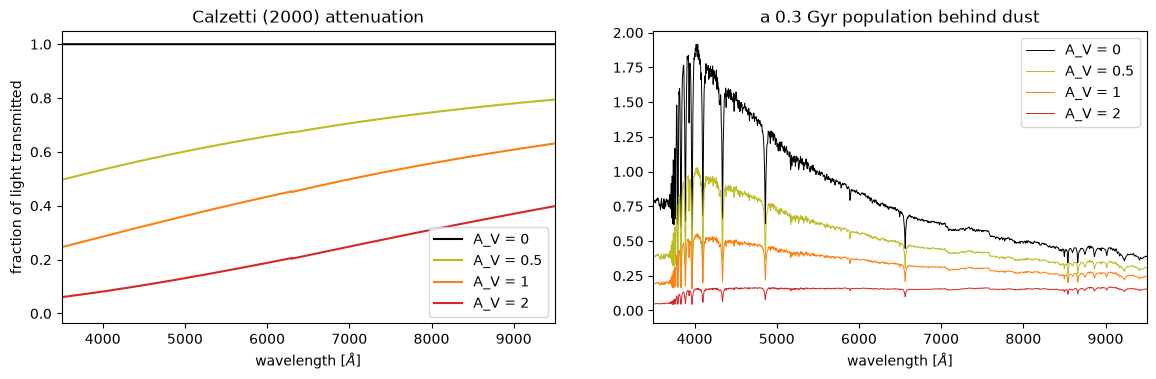

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(14, 3.8))

for A_V, c in zip([0, 0.5, 1, 2], ["k", "tab:olive", "tab:orange", "tab:red"]):
    T = attenuation(lam, A_V) if A_V else np.ones_like(lam)
    axs[0].plot(lam, T, color=c, label=f"A_V = {A_V}"); axs[1].plot(lam, broaden(ssp(0.3), sigma=100) * T, color=c, lw=0.7, label=f"A_V = {A_V}")
    print(f"A_V = {A_V}:  observed H$\\alpha$/H$\\beta$ = 2.86 x {np.interp(6563, lam, T) / np.interp(4861, lam, T):.2f} = {2.86 * np.interp(6563, lam, T) / np.interp(4861, lam, T):.2f}")
    
axs[0].set(xlim=(3500, 9500), xlabel="wavelength [$\\AA$]", ylabel="fraction of light transmitted", title="Calzetti (2000) attenuation"); axs[0].legend()
axs[1].set(xlim=(3500, 9500), xlabel="wavelength [$\\AA$]", title="a 0.3 Gyr population behind dust"); axs[1].legend(); plt.show()